In [19]:
"""
Author: Marco Montemore
Affiliation: Undergraduate Research Assistant & Student
Organization: University of Oregon - DSCI 410L (DSiA)
Date: 05/02/2026
Description: This program is designed to statistcally compare and visualize mobile crisis and first responder
             data in Eugene/Springfield, Oregon.
""";

In [46]:
# Import necessary libraries.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load the Datasets:

In [21]:
# Loading the cleaned datasets.
CAD_Data = pd.read_csv("../cleaning/Eugene_CAD_Data/CAD_CLEAN.csv")
SPD_Data = pd.read_csv("../cleaning/Springfield_SPD_Data/SPD_CLEAN.csv")
MCSLC_Data = pd.read_csv("../cleaning/MCSLC_Data/MCSLC_CLEAN.csv")

# Extract date from the Call Time column for new column. No hour or minute component.
CAD_Data['Date'] = pd.to_datetime(CAD_Data['Call Time']).dt.date
SPD_Data['Date'] = pd.to_datetime(SPD_Data['Call Time']).dt.date
MCSLC_Data['Date'] = pd.to_datetime(MCSLC_Data['Call Time']).dt.date

# Isolate CAHOOTS

In [22]:
# Use existing "Is CAHOOTS" binary classifier column = 1, make own dataframe for cahoots, using SPD and EPD datasets
CAD_CAHOOTS = CAD_Data[CAD_Data['Is CAHOOTS'] == 1]
SPD_CAHOOTS = SPD_Data[SPD_Data['Is CAHOOTS'] == 1]
# Simply combine datasets
CHT_Data = pd.concat([CAD_CAHOOTS, SPD_CAHOOTS], ignore_index=True)
# Drop agency column
CHT_Data = CHT_Data.drop(columns=['Agency'])

# Cad_Data and SPD_Data will only be rows where Is CAHOOTS doesn't equal 1.
CAD_Data = CAD_Data[CAD_Data['Is CAHOOTS'] != 1]
SPD_Data = SPD_Data[SPD_Data['Is CAHOOTS'] != 1]

# Snow Threshold Filtering

In [23]:
# Get rid of any row where "Precipitation Type" is Snow but "Snow Depth" isn't greater than 0.0.
# Not doing the same for MCSLC else little to no data would exist for it.
CAD_Data = CAD_Data[~((CAD_Data["Precipitation Type"] == "snow") & (CAD_Data["Snow Depth"] <= 0.0))]
SPD_Data = SPD_Data[~((SPD_Data["Precipitation Type"] == "snow") & (SPD_Data["Snow Depth"] <= 0.0))]
CHT_Data = CHT_Data[~((CHT_Data["Precipitation Type"] == "snow") & (CHT_Data["Snow Depth"] <= 0.0))]

# Split Data for Each Organization by Weather

In [24]:
# Split data for each dataset based on Precipitation type is nopn, rain, or snow.
CAD_Data_NoPrecip = CAD_Data[CAD_Data["Precipitation Type"] == "nopn"]
CAD_Data_Rain = CAD_Data[CAD_Data["Precipitation Type"] == "rain"]
CAD_Data_Snow = CAD_Data[CAD_Data["Precipitation Type"] == "snow"]

SPD_Data_NoPrecip = SPD_Data[SPD_Data["Precipitation Type"] == "nopn"]
SPD_Data_Rain = SPD_Data[SPD_Data["Precipitation Type"] == "rain"]
SPD_Data_Snow = SPD_Data[SPD_Data["Precipitation Type"] == "snow"]

CHT_Data_NoPrecip = CHT_Data[CHT_Data["Precipitation Type"] == "nopn"]
CHT_Data_Rain = CHT_Data[CHT_Data["Precipitation Type"] == "rain"]
CHT_Data_Snow = CHT_Data[CHT_Data["Precipitation Type"] == "snow"]

MCSLC_Data_NoPrecip = MCSLC_Data[MCSLC_Data["Precipitation Type"] == "nopn"]
MCSLC_Data_Rain = MCSLC_Data[MCSLC_Data["Precipitation Type"] == "rain"]
MCSLC_Data_Snow = MCSLC_Data[MCSLC_Data["Precipitation Type"] == "snow"]

# Simple Statistics

In [25]:
# Calcuate mean response times, 10 most common call types and closed as classes, and average call desnity. For each weather type and dataset.
# Mean response times.
Mean_Response_Time_CAD_NoPrecip = CAD_Data_NoPrecip["Seconds to Arrival"].mean()
Mean_Response_Time_CAD_Rain = CAD_Data_Rain["Seconds to Arrival"].mean()
Mean_Response_Time_CAD_Snow = CAD_Data_Snow["Seconds to Arrival"].mean()

Mean_Response_Time_SPD_NoPrecip = SPD_Data_NoPrecip["Seconds to Arrival"].mean()
Mean_Response_Time_SPD_Rain = SPD_Data_Rain["Seconds to Arrival"].mean()
Mean_Response_Time_SPD_Snow = SPD_Data_Snow["Seconds to Arrival"].mean()

Mean_Response_Time_CHT_NoPrecip = CHT_Data_NoPrecip["Seconds to Arrival"].mean()
Mean_Response_Time_CHT_Rain = CHT_Data_Rain["Seconds to Arrival"].mean()
Mean_Response_Time_CHT_Snow = CHT_Data_Snow["Seconds to Arrival"].mean()

Mean_Response_Time_MCSLC_NoPrecip = MCSLC_Data_NoPrecip["Seconds to Arrival"].mean()
Mean_Response_Time_MCSLC_Rain = MCSLC_Data_Rain["Seconds to Arrival"].mean()
Mean_Response_Time_MCSLC_Snow = MCSLC_Data_Snow["Seconds to Arrival"].mean()

# 10 most common call types.
Top_10_Call_Types_CAD_NoPrecip = CAD_Data_NoPrecip["Nature"].value_counts().head(10)
Top_10_Call_Types_CAD_Rain = CAD_Data_Rain["Nature"].value_counts().head(10)
Top_10_Call_Types_CAD_Snow = CAD_Data_Snow["Nature"].value_counts().head(10)

Top_10_Call_Types_SPD_NoPrecip = SPD_Data_NoPrecip["Nature"].value_counts().head(10)
Top_10_Call_Types_SPD_Rain = SPD_Data_Rain["Nature"].value_counts().head(10)
Top_10_Call_Types_SPD_Snow = SPD_Data_Snow["Nature"].value_counts().head(10)

Top_10_Call_Types_CHT_NoPrecip = CHT_Data_NoPrecip["Nature"].value_counts().head(10)
Top_10_Call_Types_CHT_Rain = CHT_Data_Rain["Nature"].value_counts().head(10)
Top_10_Call_Types_CHT_Snow = CHT_Data_Snow["Nature"].value_counts().head(10)

Top_10_Call_Types_MCSLC_NoPrecip = MCSLC_Data_NoPrecip["Nature"].value_counts().head(10)
Top_10_Call_Types_MCSLC_Rain = MCSLC_Data_Rain["Nature"].value_counts().head(10)
Top_10_Call_Types_MCSLC_Snow = MCSLC_Data_Snow["Nature"].value_counts().head(10)

# 10 most common closed as classes.
Top_10_Closed_As_CAD_NoPrecip = CAD_Data_NoPrecip["Closed As"].value_counts().head(10)
Top_10_Closed_As_CAD_Rain = CAD_Data_Rain["Closed As"].value_counts().head(10)
Top_10_Closed_As_CAD_Snow = CAD_Data_Snow["Closed As"].value_counts().head(10)

Top_10_Closed_As_SPD_NoPrecip = SPD_Data_NoPrecip["Closed As"].value_counts().head(10)
Top_10_Closed_As_SPD_Rain = SPD_Data_Rain["Closed As"].value_counts().head(10)
Top_10_Closed_As_SPD_Snow = SPD_Data_Snow["Closed As"].value_counts().head(10)

Top_10_Closed_As_CHT_NoPrecip = CHT_Data_NoPrecip["Closed As"].value_counts().head(10)
Top_10_Closed_As_CHT_Rain = CHT_Data_Rain["Closed As"].value_counts().head(10)
Top_10_Closed_As_CHT_Snow = CHT_Data_Snow["Closed As"].value_counts().head(10)

Top_10_Closed_As_MCSLC_NoPrecip = MCSLC_Data_NoPrecip["Closed As"].value_counts().head(10)
Top_10_Closed_As_MCSLC_Rain = MCSLC_Data_Rain["Closed As"].value_counts().head(10)
Top_10_Closed_As_MCSLC_Snow = MCSLC_Data_Snow["Closed As"].value_counts().head(10)

# Average call density (calls per day).
Average_Call_Density_CAD_NoPrecip = CAD_Data_NoPrecip.groupby("Date").size().mean()
Average_Call_Density_CAD_Rain = CAD_Data_Rain.groupby("Date").size().mean()
Average_Call_Density_CAD_Snow = CAD_Data_Snow.groupby("Date").size().mean()

Average_Call_Density_SPD_NoPrecip = SPD_Data_NoPrecip.groupby("Date").size().mean()
Average_Call_Density_SPD_Rain = SPD_Data_Rain.groupby("Date").size().mean()
Average_Call_Density_SPD_Snow = SPD_Data_Snow.groupby("Date").size().mean()

Average_Call_Density_CHT_NoPrecip = CHT_Data_NoPrecip.groupby("Date").size().mean()
Average_Call_Density_CHT_Rain = CHT_Data_Rain.groupby("Date").size().mean()
Average_Call_Density_CHT_Snow = CHT_Data_Snow.groupby("Date").size().mean()

Average_Call_Density_MCSLC_NoPrecip = MCSLC_Data_NoPrecip.groupby("Date").size().mean()
Average_Call_Density_MCSLC_Rain = MCSLC_Data_Rain.groupby("Date").size().mean()
Average_Call_Density_MCSLC_Snow = MCSLC_Data_Snow.groupby("Date").size().mean()

In [26]:
print("Mean Response Time (Seconds to Arrival):\n")
print(f"CAD Data - Nopr: {Mean_Response_Time_CAD_NoPrecip:.2f} seconds")
print(f"CAD Data - Rain: {Mean_Response_Time_CAD_Rain:.2f} seconds")
print(f"CAD Data - Snow: {Mean_Response_Time_CAD_Snow:.2f} seconds\n")

print(f"SPD Data - Nopr: {Mean_Response_Time_SPD_NoPrecip:.2f} seconds")
print(f"SPD Data - Rain: {Mean_Response_Time_SPD_Rain:.2f} seconds")
print(f"SPD Data - Snow: {Mean_Response_Time_SPD_Snow:.2f} seconds\n")

print(f"CHT Data - Nopr: {Mean_Response_Time_CHT_NoPrecip:.2f} seconds")
print(f"CHT Data - Rain: {Mean_Response_Time_CHT_Rain:.2f} seconds")
print(f"CHT Data - Snow: {Mean_Response_Time_CHT_Snow:.2f} seconds\n")

print(f"MCSLC Data - Nopr: {Mean_Response_Time_MCSLC_NoPrecip:.2f} seconds")
print(f"MCSLC Data - Rain: {Mean_Response_Time_MCSLC_Rain:.2f} seconds")
print(f"MCSLC Data - Snow: {Mean_Response_Time_MCSLC_Snow:.2f} seconds")

Mean Response Time (Seconds to Arrival):

CAD Data - Nopr: 2423.27 seconds
CAD Data - Rain: 2344.23 seconds
CAD Data - Snow: 1988.54 seconds

SPD Data - Nopr: 1000.90 seconds
SPD Data - Rain: 993.37 seconds
SPD Data - Snow: 1010.60 seconds

CHT Data - Nopr: 5236.80 seconds
CHT Data - Rain: 5306.57 seconds
CHT Data - Snow: 5509.73 seconds

MCSLC Data - Nopr: 2276.09 seconds
MCSLC Data - Rain: 2168.55 seconds
MCSLC Data - Snow: 1750.00 seconds


In [29]:
print("\nAverage Call Density (Calls per Day):\n")
print(f"CAD Data - Nopr: {Average_Call_Density_CAD_NoPrecip:.2f} calls/day")
print(f"CAD Data - Rain: {Average_Call_Density_CAD_Rain:.2f} calls/day")
print(f"CAD Data - Snow: {Average_Call_Density_CAD_Snow:.2f} calls/day\n")

print(f"SPD Data - Nopr: {Average_Call_Density_SPD_NoPrecip:.2f} calls/day")
print(f"SPD Data - Rain: {Average_Call_Density_SPD_Rain:.2f} calls/day")
print(f"SPD Data - Snow: {Average_Call_Density_SPD_Snow:.2f} calls/day\n")

print(f"CHT Data - Nopr: {Average_Call_Density_CHT_NoPrecip:.2f} calls/day")
print(f"CHT Data - Rain: {Average_Call_Density_CHT_Rain:.2f} calls/day")
print(f"CHT Data - Snow: {Average_Call_Density_CHT_Snow:.2f} calls/day\n")

print(f"MCSLC Data - Nopr: {Average_Call_Density_MCSLC_NoPrecip:.2f} calls/day")
print(f"MCSLC Data - Rain: {Average_Call_Density_MCSLC_Rain:.2f} calls/day")
print(f"MCSLC Data - Snow: {Average_Call_Density_MCSLC_Snow:.2f} calls/day")


Average Call Density (Calls per Day):

CAD Data - Nopr: 198.28 calls/day
CAD Data - Rain: 188.23 calls/day
CAD Data - Snow: 165.37 calls/day

SPD Data - Nopr: 109.95 calls/day
SPD Data - Rain: 103.11 calls/day
SPD Data - Snow: 99.77 calls/day

CHT Data - Nopr: 44.02 calls/day
CHT Data - Rain: 43.46 calls/day
CHT Data - Snow: 51.21 calls/day

MCSLC Data - Nopr: 9.19 calls/day
MCSLC Data - Rain: 8.64 calls/day
MCSLC Data - Snow: 3.43 calls/day


In [27]:
print("\n10 Most Common Call Types:\n")
print("CAD Data - Nopr:")
print(Top_10_Call_Types_CAD_NoPrecip)
print("\nCAD Data - Rain:")
print(Top_10_Call_Types_CAD_Rain)
print("\nCAD Data - Snow:")
print(Top_10_Call_Types_CAD_Snow)

print("\nSPD Data - Nopr:")
print(Top_10_Call_Types_SPD_NoPrecip)
print("\nSPD Data - Rain:")
print(Top_10_Call_Types_SPD_Rain)
print("\nSPD Data - Snow:")
print(Top_10_Call_Types_SPD_Snow)

print("\nCHT Data - Nopr:")
print(Top_10_Call_Types_CHT_NoPrecip)
print("\nCHT Data - Rain:")
print(Top_10_Call_Types_CHT_Rain)
print("\nCHT Data - Snow:")
print(Top_10_Call_Types_CHT_Snow)

print("\nMCSLC Data - Nopr:")
print(Top_10_Call_Types_MCSLC_NoPrecip)
print("\nMCSLC Data - Rain:")
print(Top_10_Call_Types_MCSLC_Rain)
print("\nMCSLC Data - Snow:")
print(Top_10_Call_Types_MCSLC_Snow)


10 Most Common Call Types:

CAD Data - Nopr:
Nature
TRAFFIC STOP             70955
PATROL CHECK             54558
DISPUTE                  36000
CRIMINAL TRESPASS        26703
PERSON STOP              22415
CHECK WELFARE            18659
FOLLOW UP                18027
DISORDERLY SUBJECT       16939
SUSPICIOUS CONDITIONS    10713
BURGLARY                  7796
Name: count, dtype: int64

CAD Data - Rain:
Nature
TRAFFIC STOP             44512
PATROL CHECK             36983
DISPUTE                  23053
CRIMINAL TRESPASS        21260
PERSON STOP              13812
FOLLOW UP                12487
CHECK WELFARE            11485
DISORDERLY SUBJECT       11079
SUSPICIOUS CONDITIONS     7287
BURGLARY                  5299
Name: count, dtype: int64

CAD Data - Snow:
Nature
TRAFFIC STOP             1621
PATROL CHECK             1509
DISPUTE                   881
CRIMINAL TRESPASS         862
FOLLOW UP                 554
DISORDERLY SUBJECT        472
CHECK WELFARE             471
PERSON STOP    

In [28]:
print("\n10 Most Common Closed As Classes:\n")
print("CAD Data - Nopr:")
print(Top_10_Closed_As_CAD_NoPrecip)
print("\nCAD Data - Rain:")
print(Top_10_Closed_As_CAD_Rain)
print("\nCAD Data - Snow:")
print(Top_10_Closed_As_CAD_Snow)

print("\nSPD Data - Nopr:")
print(Top_10_Closed_As_SPD_NoPrecip)
print("\nSPD Data - Rain:")
print(Top_10_Closed_As_SPD_Rain)
print("\nSPD Data - Snow:")
print(Top_10_Closed_As_SPD_Snow)

print("\nCHT Data - Nopr:")
print(Top_10_Closed_As_CHT_NoPrecip)
print("\nCHT Data - Rain:")
print(Top_10_Closed_As_CHT_Rain)
print("\nCHT Data - Snow:")
print(Top_10_Closed_As_CHT_Snow)

print("\nMCSLC Data - Nopr:")
print(Top_10_Closed_As_MCSLC_NoPrecip)
print("\nMCSLC Data - Rain:")
print(Top_10_Closed_As_MCSLC_Rain)
print("\nMCSLC Data - Snow:")
print(Top_10_Closed_As_MCSLC_Snow)


10 Most Common Closed As Classes:

CAD Data - Nopr:
Closed As
PATROL CHECK                       70370
ADVISED                            60165
REPORT TAKEN                       54721
ASSISTED                           36103
UNIFORM TRAFFIC CITATION ISSUED    30131
GONE ON ARRIVAL                    28175
WARNING                            25971
ARREST                             22911
UNABLE TO LOCATE                   19803
RESOLVED                           16610
Name: count, dtype: int64

CAD Data - Rain:
Closed As
PATROL CHECK                       47547
ADVISED                            40111
REPORT TAKEN                       36428
ASSISTED                           24442
WARNING                            18412
GONE ON ARRIVAL                    18222
UNIFORM TRAFFIC CITATION ISSUED    16527
ARREST                             15385
UNABLE TO LOCATE                   12474
RESOLVED                           11490
Name: count, dtype: int64

CAD Data - Snow:
Closed As
PATROL CH

# ANOVA Testing:

In [44]:
# Anova test just for CAHOOTS dataset to see if there is a significant difference in response times across weather types.
CHT_Response_Times = CHT_Data[["Seconds to Arrival", "Precipitation Type"]]
model = ols('Q("Seconds to Arrival") ~ C(Q("Precipitation Type"))', data=CHT_Response_Times).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("\nANOVA Test for CAHOOTS Response Times by Precipitation Type:\n")
print(anova_table)



ANOVA Test for CAHOOTS Response Times by Precipitation Type:

                                  sum_sq        df         F    PR(>F)
C(Q("Precipitation Type"))  4.166765e+08       2.0  3.171689  0.041935
Residual                    1.131312e+13  172228.0       NaN       NaN


Weather conditions are associated with statistically detectable differences in CAHOOTS response times, though precipitation  explains only a very small proportion of total response-time variability.

# Tukey Testing:

In [45]:
tukey = pairwise_tukeyhsd(
    endog=CHT_Data["Seconds to Arrival"],
    groups=CHT_Data["Precipitation Type"],
    alpha=0.05)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
  nopn   rain  69.7724 0.1915 -24.3851 163.9299  False
  nopn   snow 272.9368 0.1071 -43.5174  589.391  False
  rain   snow 203.1644 0.2945 -115.856 522.1848  False
------------------------------------------------------


Snow response times appear higher on average. But the variability is so large that the differences are not statistically reliable once multiple-comparison correction is applied.

CAHOOTS response times show slight upward trends under more severe precipitation conditions, particularly snow, but these differences are not statistically significant in pairwise comparisons. Agencies may compensate through operation changes during bad weather. Dispatch prioritization may adapt -> geographic/service variation may overwhelm weather effects.

# Linear Regression Model:

In [34]:
# Simple linear regression model showcasing upward trend in response times with more severe weather.
# X axis is categories no precipitation, rain, snow using y axis as all response times for each dataset.
# THe figure will be the 4 agencies' lines and their associated dots will be very transparent to prevent overplotting.

# Prepare data for linear regression plot.
Linear_Regression_Data = pd.concat([
    CAD_Data_NoPrecip.assign(Weather="Nopr", Agency="CAD"),
    CAD_Data_Rain.assign(Weather="Rain", Agency="CAD"),
    CAD_Data_Snow.assign(Weather="Snow", Agency="CAD"),
    SPD_Data_NoPrecip.assign(Weather="Nopr", Agency="SPD"),
    SPD_Data_Rain.assign(Weather="Rain", Agency="SPD"),
    SPD_Data_Snow.assign(Weather="Snow", Agency="SPD"),
    CHT_Data_NoPrecip.assign(Weather="Nopr", Agency="CHT"),
    CHT_Data_Rain.assign(Weather="Rain", Agency="CHT"),
    CHT_Data_Snow.assign(Weather="Snow", Agency="CHT"),
    MCSLC_Data_NoPrecip.assign(Weather="Nopr", Agency="MCSLC"),
    MCSLC_Data_Rain.assign(Weather="Rain", Agency="MCSLC"),
    MCSLC_Data_Snow.assign(Weather="Snow", Agency="MCSLC")
], ignore_index=True)

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


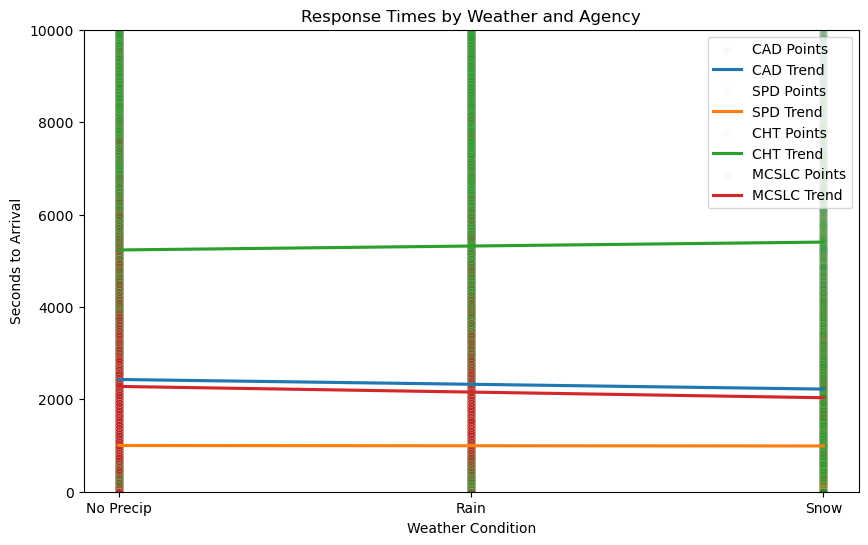

In [37]:
# Encode weather categories numerically.
weather_mapping = {
    "Nopr": 0,
    "Rain": 1,
    "Snow": 2
}

Linear_Regression_Data["Weather_Code"] = (
    Linear_Regression_Data["Weather"]
    .map(weather_mapping)
)

# Create figure.
plt.figure(figsize=(10, 6))

# Regression lines by agency.
for agency in Linear_Regression_Data["Agency"].unique():

    agency_data = Linear_Regression_Data[
        Linear_Regression_Data["Agency"] == agency
    ]

    # Transparent scatter points.
    sns.scatterplot(
        x="Weather_Code",
        y="Seconds to Arrival",
        data=agency_data,
        alpha=0.03,
        label=f"{agency} Points"
    )

    # Regression line.
    sns.regplot(
        x="Weather_Code",
        y="Seconds to Arrival",
        data=agency_data,
        scatter=False,
        ci=None,
        label=f"{agency} Trend"
    )

# Custom x-axis labels.
plt.xticks([0, 1, 2], ["No Precip", "Rain", "Snow"])

plt.title("Response Times by Weather and Agency")
plt.xlabel("Weather Condition")
plt.ylabel("Seconds to Arrival")
plt.ylim(0, 10000)  # Limit y-axis to 99th percentile to reduce outlier impact.

plt.legend()
plt.show()

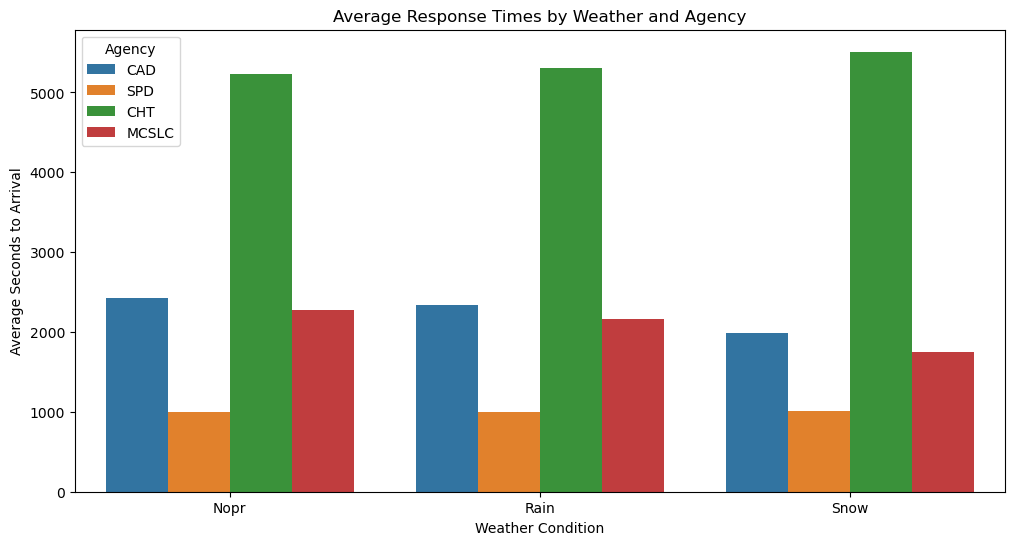

In [48]:
# Paired bar chart comparing average response times across weather types for each agency.
# Prepare data for bar chart.
Bar_Chart_Data = pd.DataFrame({
    "Agency": ["CAD", "CAD", "CAD", "SPD", "SPD", "SPD", "CHT", "CHT", "CHT", "MCSLC", "MCSLC", "MCSLC"],
    "Weather": ["Nopr", "Rain", "Snow"] * 4,
    "Mean_Response_Time": [
        Mean_Response_Time_CAD_NoPrecip, Mean_Response_Time_CAD_Rain, Mean_Response_Time_CAD_Snow,
        Mean_Response_Time_SPD_NoPrecip, Mean_Response_Time_SPD_Rain, Mean_Response_Time_SPD_Snow,
        Mean_Response_Time_CHT_NoPrecip, Mean_Response_Time_CHT_Rain, Mean_Response_Time_CHT_Snow,
        Mean_Response_Time_MCSLC_NoPrecip, Mean_Response_Time_MCSLC_Rain, Mean_Response_Time_MCSLC_Snow
    ]
})
plt.figure(figsize=(12, 6))
sns.barplot(x="Weather", y="Mean_Response_Time", hue="Agency", data=Bar_Chart_Data)
plt.title("Average Response Times by Weather and Agency")
plt.xlabel("Weather Condition")
plt.ylabel("Average Seconds to Arrival")
plt.legend(title="Agency")
plt.show()

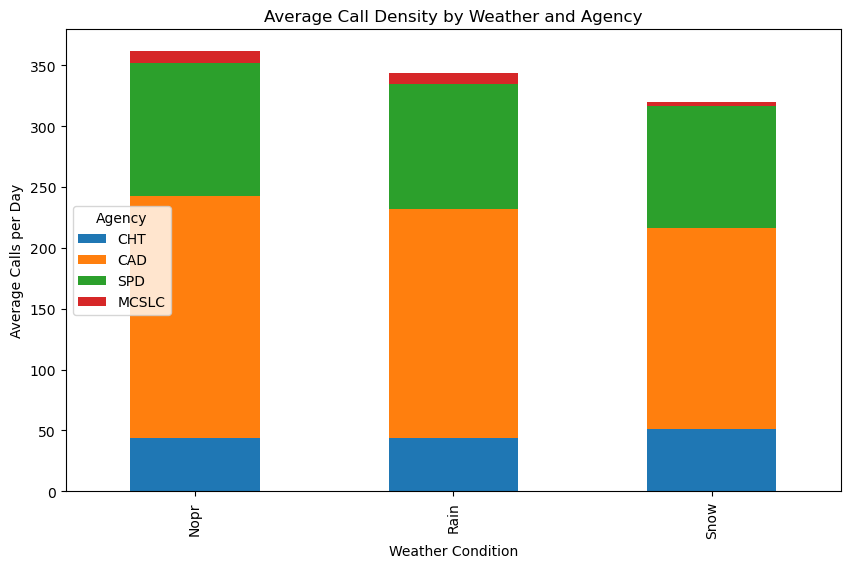

In [51]:
# Stacked barplot of 4 agencies by call density for each weather type average calls per day.
# Weather is x axis and average calls per day is y axis with 4 bars for each weather type representing the 4 agencies.

# Prepare data for stacked bar chart.
Stacked_Bar_Chart_Data = pd.DataFrame({
    "Weather": ["Nopr", "Rain", "Snow"],
    "CHT": [
        Average_Call_Density_CHT_NoPrecip,
        Average_Call_Density_CHT_Rain,
        Average_Call_Density_CHT_Snow
    ],
    "CAD": [
        Average_Call_Density_CAD_NoPrecip,
        Average_Call_Density_CAD_Rain,
        Average_Call_Density_CAD_Snow
    ],
    "SPD": [
        Average_Call_Density_SPD_NoPrecip,
        Average_Call_Density_SPD_Rain,
        Average_Call_Density_SPD_Snow
    ],
    "MCSLC": [
        Average_Call_Density_MCSLC_NoPrecip,
        Average_Call_Density_MCSLC_Rain,
        Average_Call_Density_MCSLC_Snow
    ]
})

Stacked_Bar_Chart_Data.set_index("Weather", inplace=True)
Stacked_Bar_Chart_Data.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Average Call Density by Weather and Agency")
plt.xlabel("Weather Condition")
plt.ylabel("Average Calls per Day")
plt.legend(title="Agency")
plt.show()

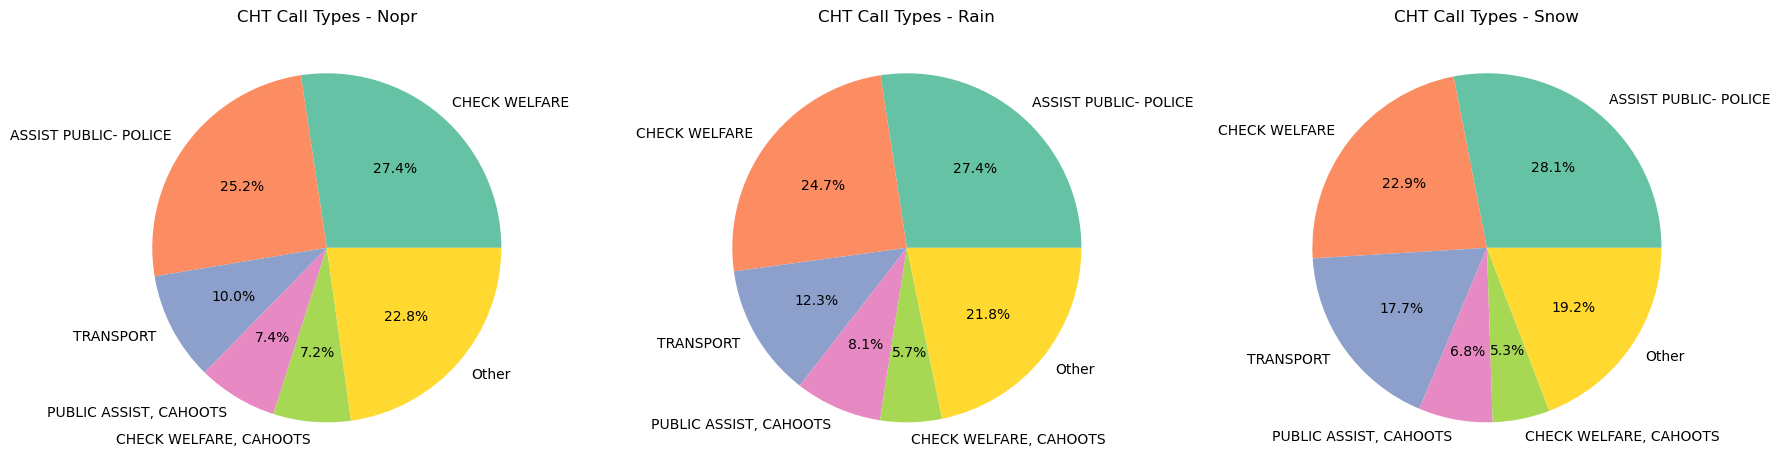

In [47]:
# 3 Pie charts for CHAOOTS dataset showing distribution of call types for each weather condition.
# Prepare data for pie charts.
CHT_Call_Type_Distribution = {
    "Nopr": CHT_Data_NoPrecip["Nature"].value_counts(),
    "Rain": CHT_Data_Rain["Nature"].value_counts(),
    "Snow": CHT_Data_Snow["Nature"].value_counts()
}
# Create figure with 3 subplots.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Plot pie charts, label the top 5 call types and group the rest as "Other".
# Have the color classifications be fixed across all 3 charts for consistency.

for i, (weather, distribution) in enumerate(CHT_Call_Type_Distribution.items()):
    top_5 = distribution.head(5)
    others = distribution[5:].sum()
    labels = list(top_5.index) + ["Other"]
    sizes = list(top_5.values) + [others]
    colors = sns.color_palette("Set2", len(labels))
    axes[i].pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors)
    axes[i].set_title(f"CHT Call Types - {weather}")
plt.tight_layout()
plt.show()


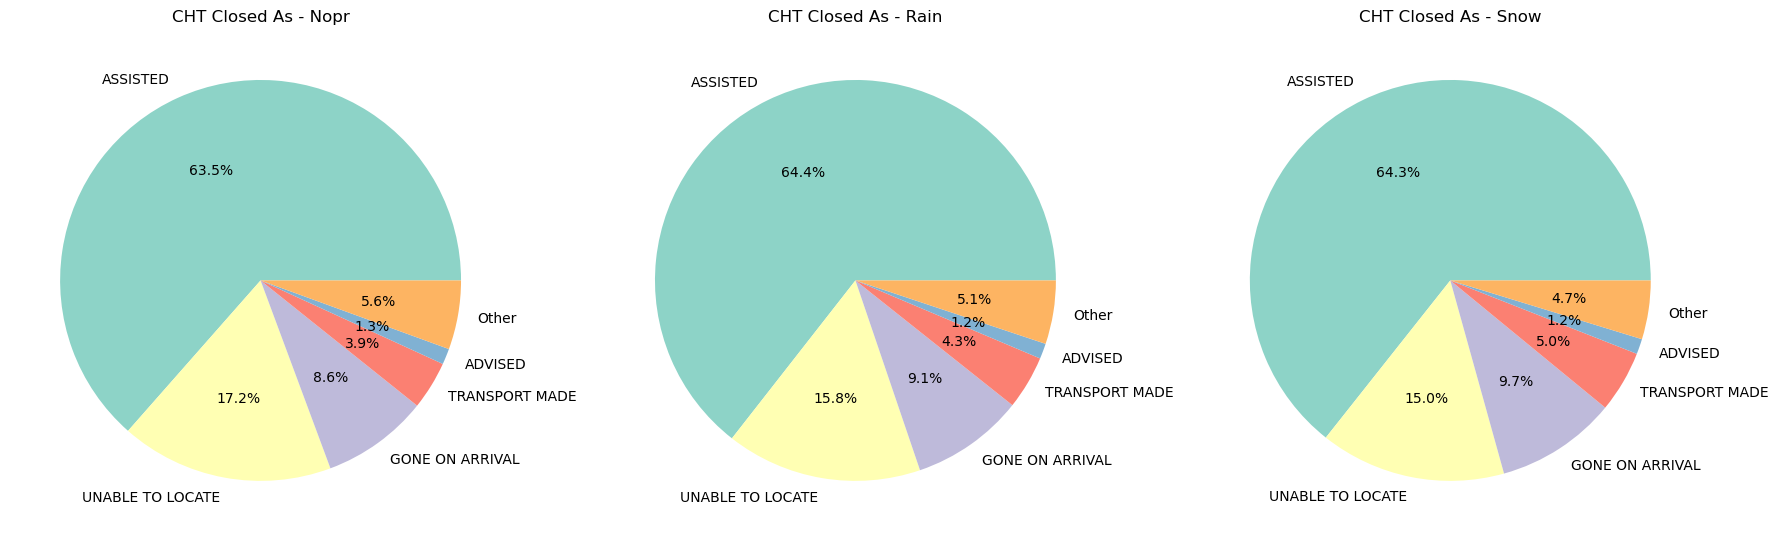

In [52]:
# Now do the same for closed as classes for CAHOOTS dataset.
# Prepare data for pie charts.
CHT_Closed_As_Distribution = {
    "Nopr": CHT_Data_NoPrecip["Closed As"].value_counts(),
    "Rain": CHT_Data_Rain["Closed As"].value_counts(),
    "Snow": CHT_Data_Snow["Closed As"].value_counts()
}

# Create figure with 3 subplots.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Plot pie charts, label the top 5 closed as classes and group the rest as "Other".
for i, (weather, distribution) in enumerate(CHT_Closed_As_Distribution.items()):
    top_5 = distribution.head(5)
    others = distribution[5:].sum()
    labels = list(top_5.index) + ["Other"]
    sizes = list(top_5.values) + [others]
    colors = sns.color_palette("Set3", len(labels))
    axes[i].pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors)
    axes[i].set_title(f"CHT Closed As - {weather}")
plt.tight_layout()
plt.show()